<a href="https://colab.research.google.com/github/thornton330j/IS-4487/blob/main/Assignments/assignment_13_ThorntonJackson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Total number of reviews imported: 1000

Percentage of reviews:
Liked
1    50.0
0    50.0
Name: proportion, dtype: float64


/tmp/ipykernel_537/1532714512.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=like_counts.index, y=like_counts.values, palette='viridis')


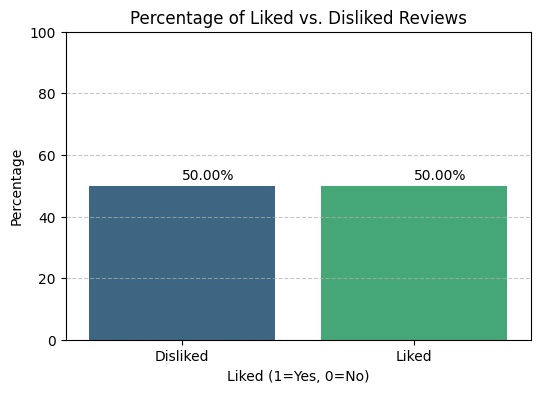

In [2]:
# Add code here 🔧
import matplotlib.pyplot as plt
import seaborn as sns

# Verify that rows were imported correctly
num_rows = df.shape[0]
print(f"Total number of reviews imported: {num_rows}")

# Calculate percentage of reviews that liked the restaurant
like_counts = df['Liked'].value_counts(normalize=True) * 100
print("\nPercentage of reviews:")
print(like_counts)

# Create bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=like_counts.index, y=like_counts.values, palette='viridis')
plt.title('Percentage of Liked vs. Disliked Reviews')
plt.xlabel('Liked (1=Yes, 0=No)')
plt.ylabel('Percentage')
plt.xticks(ticks=[0, 1], labels=['Disliked', 'Liked'])
plt.ylim(0, 100)

for index, value in enumerate(like_counts.values):
    plt.text(index, value + 2, f'{value:.2f}%')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [3]:
# Add code here 🔧
import re

# Change reviews to lowercase letters
def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs (a common pattern for URLs)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove anything that isn't a regular character
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['Review_Cleaned'] = df['Review'].apply(preprocess_text)
display(df[['Review', 'Review_Cleaned']].head())

,Review,Review_Cleaned
0,Wow... Loved this place.,wow loved this place
1,Crust is not good.,crust is not good
2,Not tasty and the texture was just nasty.,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,the selection on the menu was great and so wer...


### ✍️ Your Response: 🔧
1. Increased noise, reduced accuracy, higher dimensionality, and misinterpretation could all be included if "junk" were to be included.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [4]:
# Add code here 🔧
# Install VADER
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment(text):
    vs = analyzer.polarity_scores(text)
    if vs['compound'] >= 0.05:
        return 'Positive'
    elif vs['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis
df['Sentiment'] = df['Review_Cleaned'].apply(get_sentiment)

# Calculate percentages of reviews
sentiment_counts = df['Sentiment'].value_counts(normalize=True) * 100
print("\nPercentage of reviews by Sentiment:")
print(sentiment_counts)

# Show
display(df[['Review', 'Review_Cleaned', 'Sentiment', 'Liked']].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00

Percentage of reviews by Sentiment:
Sentiment
Positive    50.6
Negative    25.5
Neutral     23.9
Name: proportion, dtype: float64


,Review,Review_Cleaned,Sentiment,Liked
0,Wow... Loved this place.,wow loved this place,Positive,1
1,Crust is not good.,crust is not good,Negative,0
2,Not tasty and the texture was just nasty.,not tasty and the texture was just nasty,Negative,0
3,Stopped by during the late May bank holiday of...,stopped by during the late may bank holiday of...,Positive,1
4,The selection on the menu was great and so wer...,the selection on the menu was great and so wer...,Positive,1


### ✍️ Your Response: 🔧
1. The liked column showed an even 50-50 split. Negative showed 25.5% and neutral showed 23.9%. This indicates that while 50% of reviews explicitly stated they liked the restaurant, VADER found slightly more positive sentiment overall.

2. From a restaurant owner's perspective, negative reviews would be the most important to analyze. These reviews directly highlight areas of dissatisfaction that needs immediate attention and improvement. Addressing these can prevent future customer churn and improve overall reputation.
While positive reviews are great for morale and marketing, they are generally less critical for identifying areas for improvement compared to negative and neutral.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [7]:
# Add code here 🔧
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function for tokenization
def process_review_for_topic_modeling(text):
    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and perform lemmatization
    processed_tokens = []
    for word in tokens:
        if word.isalpha() and word not in stop_words: # Ensure it's an alphabet and not a stopword
            processed_tokens.append(lemmatizer.lemmatize(word))
    return processed_tokens

# Apply the preprocessing function
df['Review_Processed'] = df['Review_Cleaned'].apply(process_review_for_topic_modeling)

# Display
for i, review in enumerate(df['Review_Processed'].head(10)):
    print(f"Review {i+1}: {review}")

Review 1: ['wow', 'loved', 'place']
Review 2: ['crust', 'good']
Review 3: ['tasty', 'texture', 'nasty']
Review 4: ['stopped', 'late', 'may', 'bank', 'holiday', 'rick', 'steve', 'recommendation', 'loved']
Review 5: ['selection', 'menu', 'great', 'price']
Review 6: ['getting', 'angry', 'want', 'damn', 'pho']
Review 7: ['honeslty', 'didnt', 'taste', 'fresh']
Review 8: ['potato', 'like', 'rubber', 'could', 'tell', 'made', 'ahead', 'time', 'kept', 'warmer']
Review 9: ['fry', 'great']
Review 10: ['great', 'touch']


### ✍️ Your Response: 🔧
1. A corpus is a large collection of texts used for research and analysis. It serves as a sample of a language or a specific domain of language. In text analysis, corpora are used to train and evaluate language processing models, identify patterns, understand word frequencies, contexts, and grammatical structures.

2. Applying tokenization, the tokens would be wow, loved, this, and place. If stopwords were removed and lemmatization applied, the tokens for topic modeling would be wow, love, and place.

3. Lemmatization is the process of reducing inflected forms of a word to its base or dictionary form. Lemmatization uses vocabulary and morphological analysis of words to return the root form. It can help to reduce the dimensionality of the data by treating different grammatical forms of the same word as a single term, improving accuracy and interpretability of the topics.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [10]:
# Add code here 🔧
from gensim.corpora.dictionary import Dictionary
from gensim.models.ldamodel import LdaModel

# Create a dictionary
dictionary = Dictionary(df['Review_Processed'])

# Filter out words
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Create a bag-of-words corpus
corpus = [dictionary.doc2bow(text) for text in df['Review_Processed']]

# Display a summary
print("Dictionary summary:")
print(f"Number of unique tokens: {len(dictionary)}")
print("Sample word from dictionary:")
if len(dictionary) > 0:
    print(f"ID 0: {dictionary[0]}")

print("\nCorpus summary (first 5 documents):")
for i, doc in enumerate(corpus[:5]):
    print(f"Document {i+1}: {doc}")

Dictionary summary:
Number of unique tokens: 256
Sample word from dictionary:
ID 0: loved

Corpus summary (first 5 documents):
Document 1: [(0, 1), (1, 1)]
Document 2: [(2, 1)]
Document 3: [(3, 1)]
Document 4: [(0, 1), (4, 1)]
Document 5: [(5, 1), (6, 1), (7, 1), (8, 1)]


### ✍️ Your Response: 🔧
1. In the context of topic modeling with Gensim, a corpus is a collection of documents represented in a structured, numerical format, typically as a bag-of-words. Each document in the corpus is represented as a list, where word_id refers to a unique integer assigned to each word in the dictionary, and word_count is the frequency of that word in the document. It is useful by transforming raw text into a format that machine learning models can understand and process efficiently.

2. A dictionary is a mapping between tokens and unique integer IDs. It  creates a numerical representation for every unique word encountered in the entire collection of documents. A corpus is built using the dictionary. It represents each document as a sequence of word_id and word_count pairs. So, while the dictionary defines what words exist and their numerical identifiers, the corpus tells which words appear and how many times they appear.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [14]:
# Add code here 🔧
from gensim.models.ldamodel import LdaModel

# Select the number of topics
num_topics = 5

# Build the LDA model
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=100)

### ✍️ Your Response: 🔧
1. You might use more than 5 topics if the initial topics are too broad or generalized. If you're looking for very specific insights or niche aspects mentioned in the reviews, a higher number of topics might be necessary to isolate those smaller themes.

2.  Having redundant or overlapping topics, incoherent or uninterpretable topics, topics with few dominant words, or difficulty interpreting could all be signs of having too many topics.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"

LDA Model Topics:
Topic 0: 0.038*"place" + 0.035*"amazing" + 0.028*"delicious" + 0.028*"pizza" + 0.028*"came" + 0.027*"nice" + 0.021*"salad" + 0.020*"wasnt" + 0.018*"taste" + 0.018*"good"
Topic 1: 0.075*"back" + 0.062*"good" + 0.042*"go" + 0.035*"best" + 0.028*"place" + 0.026*"ever" + 0.022*"star" + 0.020*"wont" + 0.019*"going" + 0.018*"also"
Topic 2: 0.127*"food" + 0.054*"service" + 0.053*"place" + 0.038*"great" + 0.031*"like" + 0.027*"would" + 0.026*"good" + 0.019*"never" + 0.019*"say" + 0.019*"really"
Topic 3: 0.073*"time" + 0.048*"great" + 0.022*"service" + 0.022*"place" + 0.021*"get" + 0.021*"table" + 0.020*"vega" + 0.020*"always" + 0.019*"think" + 0.018*"minute"
Topic 4: 0.031*"really" + 0.029*"chicken" + 0.026*"restaurant" + 0.024*"service" + 0.023*"flavor" + 0.023*"food" + 0.023*"disappointed" + 0.021*"enough" + 0.021*"bad" + 0.021*"good"

Dominant Topic for each Review (first 5 rows):


,Dominant_Topic,Perc_Contribution,Topic_Keywords,Text,Original_Review,Sentiment,Liked
0,3,0.7263,"time, great, service, place, get, table, vega,...",wow loved this place,Wow... Loved this place.,Positive,1
1,1,0.5963,"back, good, go, best, place, ever, star, wont,...",crust is not good,Crust is not good.,Negative,0
2,0,0.5983,"place, amazing, delicious, pizza, came, nice, ...",not tasty and the texture was just nasty,Not tasty and the texture was just nasty.,Negative,0
3,3,0.7328,"time, great, service, place, get, table, vega,...",stopped by during the late may bank holiday of...,Stopped by during the late May bank holiday of...,Positive,1
4,4,0.4412,"really, chicken, restaurant, service, flavor, ...",the selection on the menu was great and so wer...,The selection on the menu was great and so wer...,Positive,1



Frequency of Each Topic:
Dominant_Topic
0    21.5
1    22.8
2    23.1
3    16.4
4    16.2
Name: proportion, dtype: float64

Word Clouds for Each Topic:


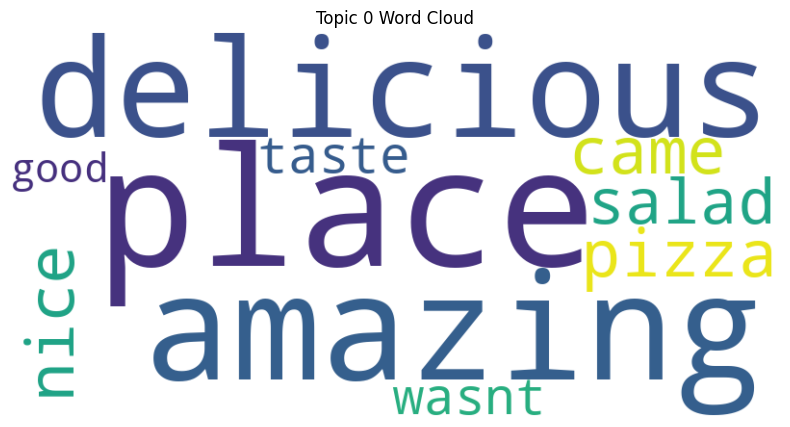

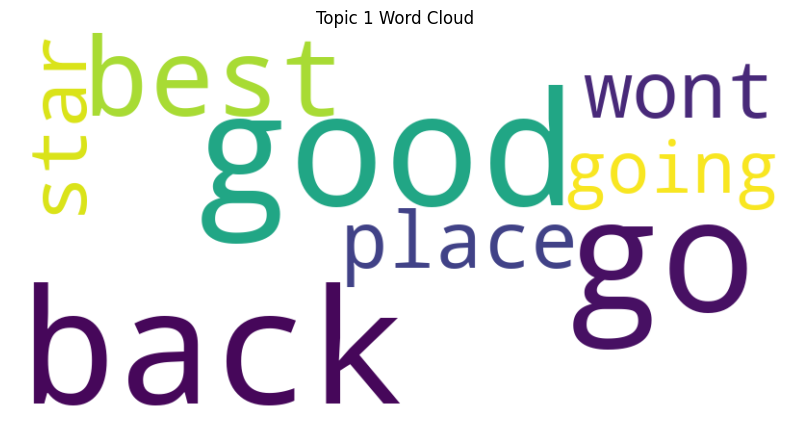

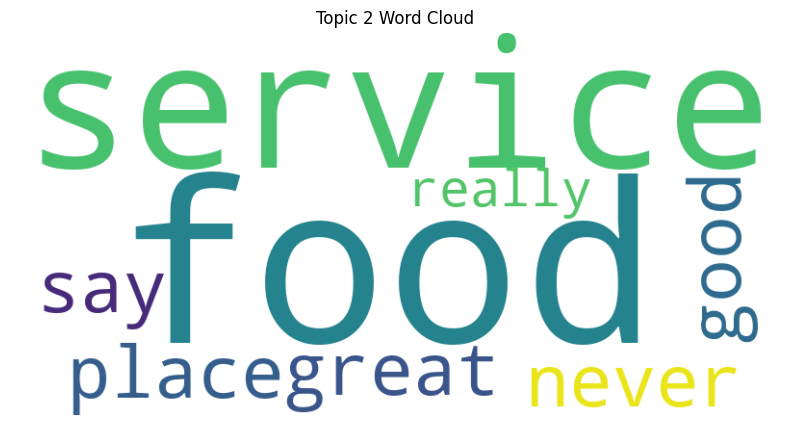

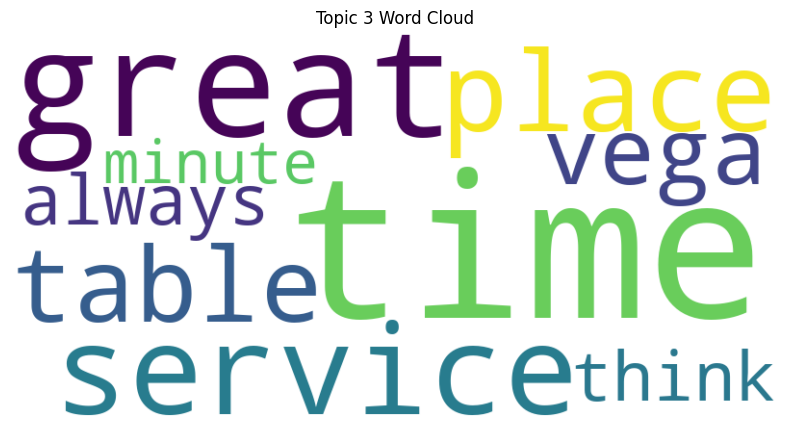

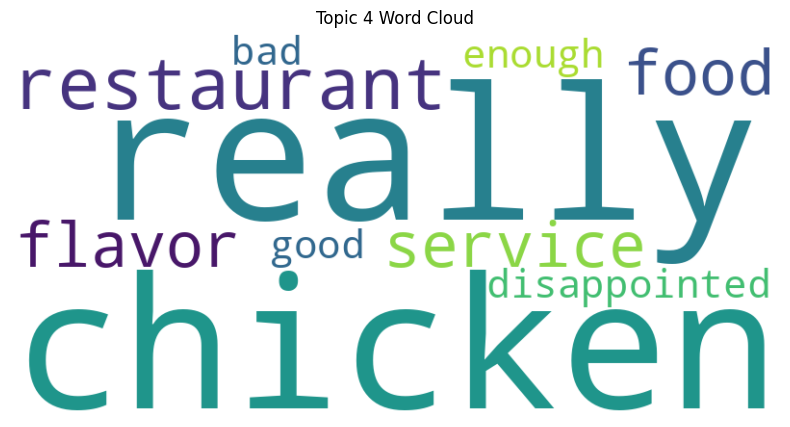


Sentiment Distribution by Topic (in %):


Sentiment,Negative,Neutral,Positive
Dominant_Topic,,,
0,23.255814,24.651163,52.093023
1,24.561404,25.438596,50.000000
2,25.974026,19.047619,54.978355
3,26.219512,31.097561,42.682927
4,28.395062,20.370370,51.234568


In [25]:
# Add code here 🔧
# Print the topics and top 10 words
print("LDA Model Topics:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

# Display the first few rows of the dominant topic dataframe
print("\nDominant Topic for each Review (first 5 rows):")
display(df_topic_sents_keywords.head())

# Calculate topic frequencies
topic_counts = df_topic_sents_keywords['Dominant_Topic'].value_counts(normalize=True).sort_index() * 100
print("\nFrequency of Each Topic:")
print(topic_counts)

# Word cloud
def create_wordcloud(topic_words, topic_id):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(topic_words)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Topic {topic_id} Word Cloud')
    plt.axis('off')
    plt.show()

print("\nWord Clouds for Each Topic:")
for i, topic_words in lda_model.show_topics(formatted=False):
    words = ' '.join([word for word, prop in topic_words])
    create_wordcloud(words, i)

# Summarize sentiment by topic
sentiment_by_topic = df_topic_sents_keywords.groupby('Dominant_Topic')['Sentiment'].value_counts(normalize=True).unstack().fillna(0) * 100

print("\nSentiment Distribution by Topic (in %):")
display(sentiment_by_topic)

### ✍️ Your Response: 🔧
Topics:
- Topic 0: Food & Atmosphere
- Topic 1: Return Visits
- Topic 2: Overall Experience
- Topic 3: Service & Timing
- Topic 4: Food Satisfaction

## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response: 🔧
1. The model helped answer "What are the main themes expressed by customers in their reviews, and how do these relate to overall satisfaction."

2.  I would reccomend this resturant to focus on service and timing, address negative feedback, and to leverage return visits insights.

3. - Pros: Ease of use and speed, interpretation and no library dependencies.
   - Cons: Lack of control, bias, Scalability and customization.

4. I would tell the LLM, "You are an expert text analyst specializing in restaurant customer feedback. Your task is to analyze a dataset of restaurant reviews to identify key themes, determine sentiment, and provide actionable insights. First, clean the reviews by removing punctuation, URLs, and making them lowercase to prepare for analysis. Then, classify each review's sentiment and identify 5 distinct topics. Finally, calculate the overall sentiment distribution and the frequency of each topic, then offer 3-5 specific recommendations to improve customer satisfaction, prioritizing negative feedback."

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [26]:
!jupyter nbconvert --to html "assignment_13_ThorntonJackson.ipynb"

[NbConvertApp] Converting notebook assignment_13_ThorntonJackson.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 998271 bytes to assignment_13_ThorntonJackson.html
